In [2]:
import os
from pathlib import Path
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
import matplotlib.pyplot as plt
import preprocessing
from PIL import Image
import model_evaluation
import models_and_training
import preprocessing

In [3]:
PROJECT_ROOT = Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "data"

In [4]:
# https://docs.pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html
base_ds = datasets.ImageFolder(root=DATA_DIR)
base_ds

Dataset ImageFolder
    Number of datapoints: 947
    Root location: /home/genslin/Documents/Purdue/NUCL575/Project/code/flow_classification/data

In [5]:
folder_index = np.array([index for _, index in base_ds.samples])

In [6]:
data_stats = []
for flow_type in os.listdir(DATA_DIR):
    num_images = len(os.listdir(DATA_DIR / flow_type))
    data_stats.append({"Flow Type": flow_type, "Image Count": num_images})

data_stats = pd.DataFrame(data_stats)
data_stats

,Flow Type,Image Count
0,Taylor,267
1,Churn,117
2,Slug,285
3,Bubbly,278


In [7]:
rng = 42

# Split data into train and test/val sets
# https://scikit-learn.org/stable/modules/cross_validation.html#stratified-shuffle-split
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedShuffleSplit.html

# In an image each pixels RGB values is a feature, for the sake of splitting in 
# this classification problem we only need to consider the classification of the image itself first
dummy_features = np.zeros_like(folder_index)
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=rng)
train_index, test_and_val_index = next(sss1.split(dummy_features, folder_index))

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=rng)
test_and_val_lables = folder_index[test_and_val_index]
dummy_features = np.zeros_like(test_and_val_lables)
test_index_rel, val_index_rel = next(sss2.split(dummy_features, test_and_val_lables))

# Second SSS splits relative to the index of test_and_val lables so these need
# to be mapped back to original indices
test_index = test_and_val_index[test_index_rel]
val_index  = test_and_val_index[val_index_rel]

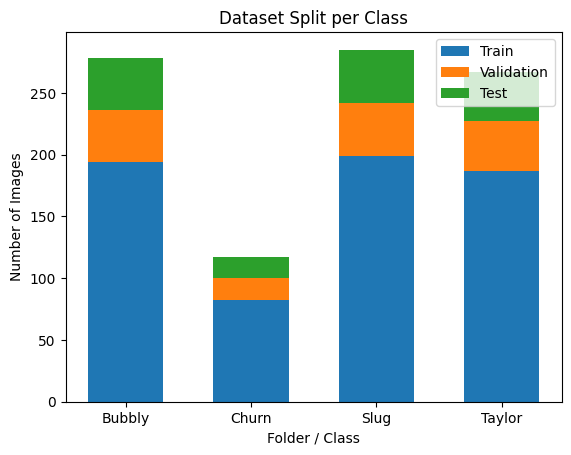

In [8]:
class_names = list(base_ds.class_to_idx.keys())
classes = np.arange(len(class_names))

train_counts = [np.sum(folder_index[train_index] == i) for i in classes]
val_counts   = [np.sum(folder_index[val_index] == i) for i in classes]
test_counts  = [np.sum(folder_index[test_index] == i) for i in classes]

fig, ax = plt.subplots()
bar_width = 0.6
ax.bar(class_names, train_counts, label='Train', color='tab:blue', width=bar_width)
ax.bar(class_names, val_counts, bottom=train_counts, label='Validation', color='tab:orange', width=bar_width)
ax.bar(class_names, test_counts, bottom=np.array(train_counts)+np.array(val_counts), 
       label='Test', color='tab:green', width=bar_width)

ax.set_xlabel('Folder / Class')
ax.set_ylabel('Number of Images')
ax.set_title('Dataset Split per Class')
ax.legend()

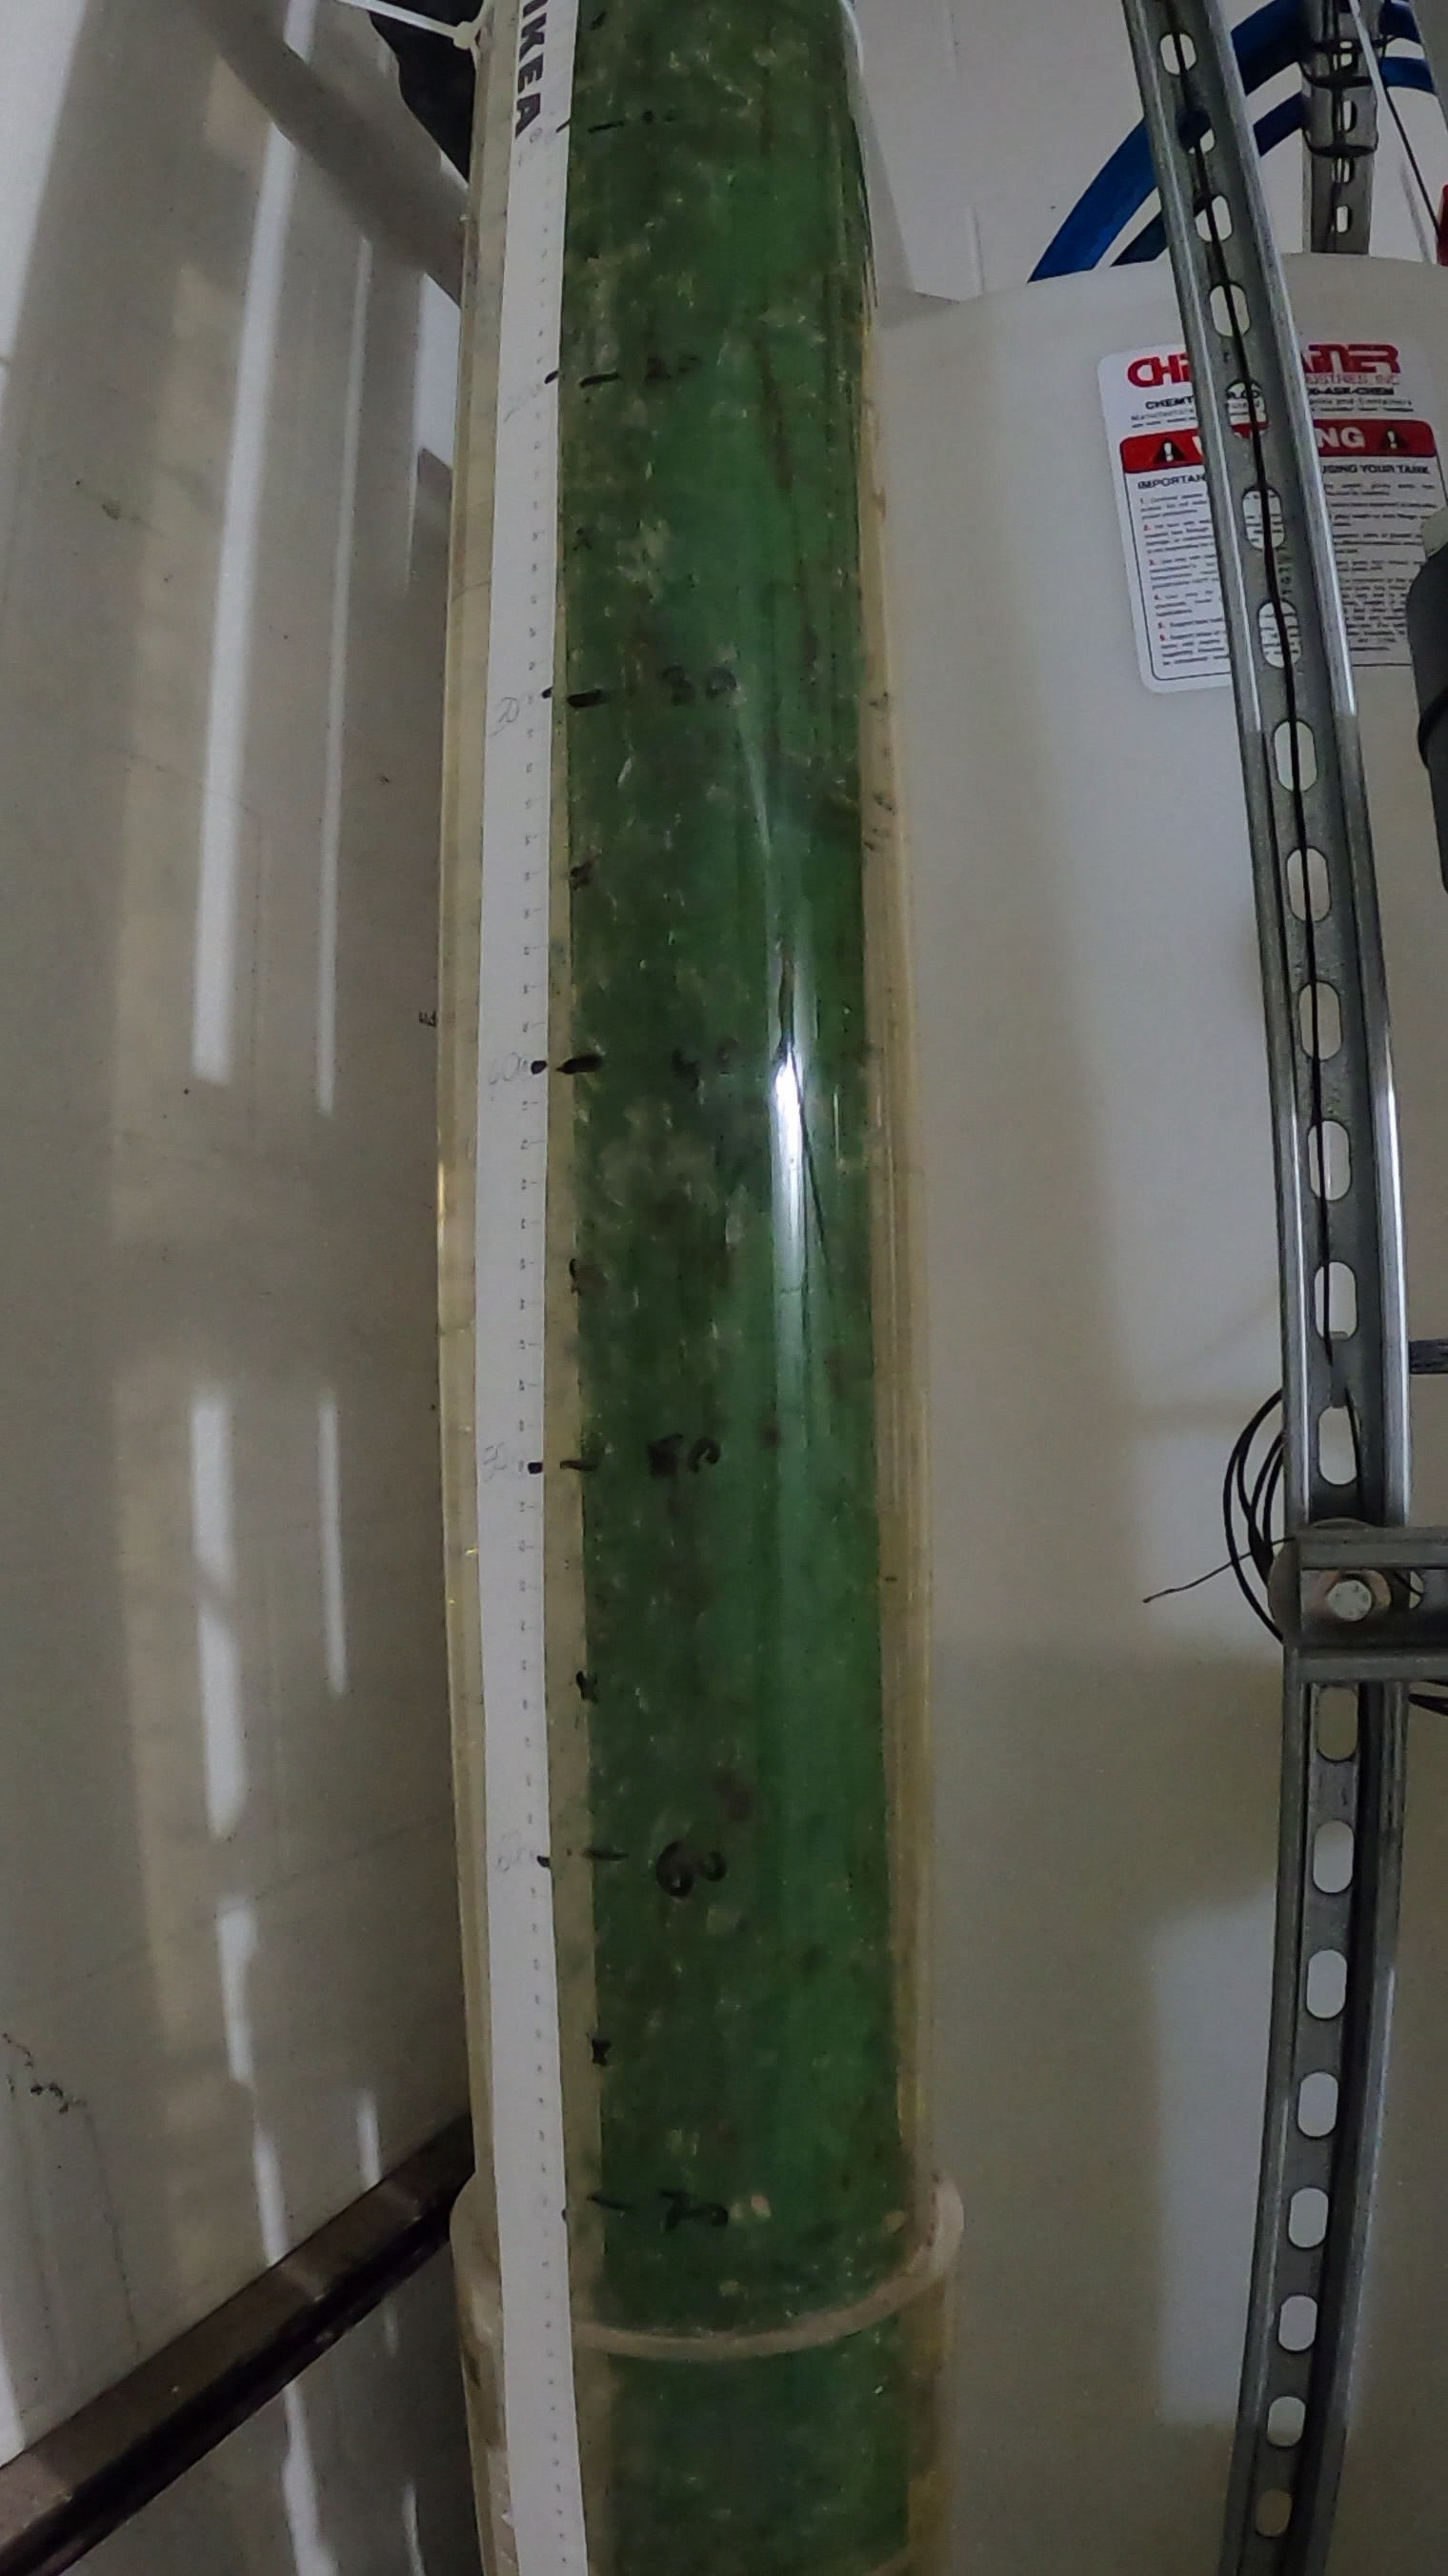

In [9]:
# Unmodified Image
img = Image.open(r'data/Bubbly/68_15_7_02_p1.jpg')
img

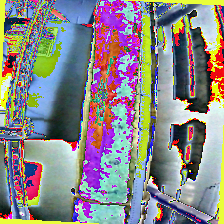

In [10]:
# Image after transform
tf = preprocessing.get_train_transform()
transformed_image = tf(img)
transforms.ToPILImage()(transformed_image)

In [11]:
# Loading a pretrained CNN model and using it to predict classifcations, 
# demonstrates random chance at this point
loader = preprocessing.get_quick_test_loader()
model = models_and_training.get_pre_trained_resnet18()
model_evaluation.evaluate_accuracy(model, loader)

/home/genslin/Documents/Purdue/NUCL575/Project/code/flow_classification/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


0.29577464788732394

In [13]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  